## 01 — Building the Grid Index

We understand the concept. Now we implement the data structure.

The grid index has two operations:
- `build(features)` — assigns every feature to the cells it overlaps
- `query(viewport_bbox)` — returns features from the cells the viewport touches

This notebook covers `build`. The next covers `query` and benchmarking.

## Setup

In [1]:
import json
from pathlib import Path

with open(Path("../../data/lod/railroads_fine.geojson")) as f:
    fine = json.load(f)

features = fine["features"]
print(f"Fine LOD: {len(features):,} features")

Fine LOD: 25,413 features


In [2]:
def feature_bbox(feature):
    coords = feature["geometry"]["coordinates"]
    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    return [min(lons), min(lats), max(lons), max(lats)]

## The GridIndex Class

The core data structure is a dict mapping `(col, row)` tuples to lists of `(index, feature)` pairs.

We store the original index alongside each feature so we can deduplicate efficiently during queries — a feature that spans multiple cells should only appear once in the query result.

In [3]:
class GridIndex:
    """
    A uniform grid spatial index for GeoJSON LineString features.

    The world is divided into cells of `cell_size` degrees.
    Each feature is stored in every cell whose bbox it overlaps.
    """

    def __init__(self, cell_size=10.0):
        self.cell_size = cell_size
        self.cells = {}   # (col, row) -> list of (feature_index, feature)
        self.n_features = 0

    def _cells_for_bbox(self, bbox):
        """Return all (col, row) tuples that the given bbox overlaps."""
        lon_min, lat_min, lon_max, lat_max = bbox
        col_min = int((lon_min + 180) / self.cell_size)
        col_max = int((lon_max + 180) / self.cell_size)
        row_min = int((lat_min +  90) / self.cell_size)
        row_max = int((lat_max +  90) / self.cell_size)
        return [
            (col, row)
            for col in range(col_min, col_max + 1)
            for row in range(row_min, row_max + 1)
        ]

    def build(self, features):
        """Populate the index from a list of GeoJSON features."""
        self.cells = {}
        self.n_features = len(features)

        for idx, feature in enumerate(features):
            bbox = feature_bbox(feature)
            for cell in self._cells_for_bbox(bbox):
                if cell not in self.cells:
                    self.cells[cell] = []
                self.cells[cell].append((idx, feature))

    def query(self, viewport_bbox):
        """Return features from all cells the viewport overlaps. Deduplicates."""
        seen = set()
        results = []
        for cell in self._cells_for_bbox(viewport_bbox):
            for idx, feature in self.cells.get(cell, []):
                if idx not in seen:
                    seen.add(idx)
                    results.append(feature)
        return results

    def stats(self):
        """Print summary statistics about the index."""
        occupied   = len(self.cells)
        total_refs = sum(len(v) for v in self.cells.values())
        max_cell   = max((len(v), k) for k, v in self.cells.items())
        print(f"Cell size:         {self.cell_size}°")
        print(f"Features indexed:  {self.n_features:,}")
        print(f"Occupied cells:    {occupied:,}")
        print(f"Total references:  {total_refs:,}  (features × cells they span)")
        print(f"Avg refs/cell:     {total_refs / occupied:.1f}")
        print(f"Busiest cell:      {max_cell[1]}  ({max_cell[0]} features)")

## Building and Inspecting the Index

In [4]:
import time

index = GridIndex(cell_size=10.0)

t0 = time.perf_counter()
index.build(features)
build_time = time.perf_counter() - t0

print(f"Build time: {build_time:.3f}s\n")
index.stats()

Build time: 0.036s

Cell size:         10.0°
Features indexed:  25,413
Occupied cells:    188
Total references:  26,571  (features × cells they span)
Avg refs/cell:     141.3
Busiest cell:      (19, 14)  (3325 features)


## Visualizing Cell Density

Let's plot the grid as a heatmap — how many features are assigned to each cell?

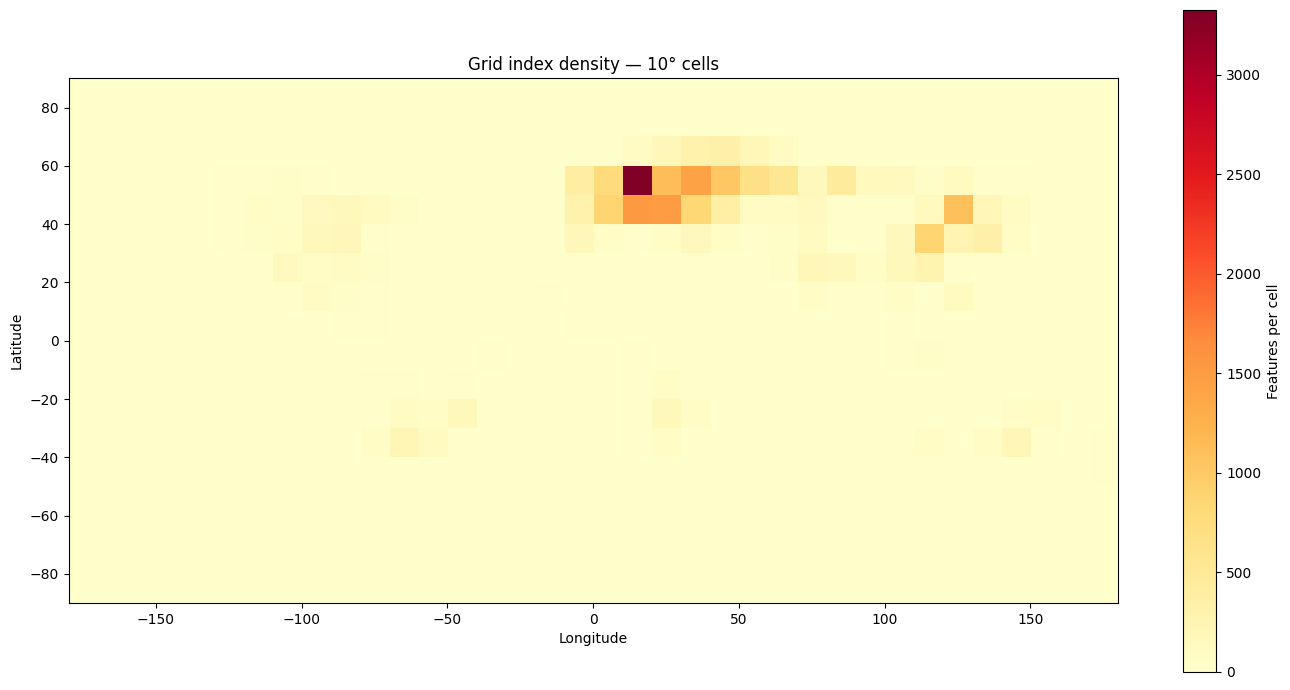

In [5]:
import matplotlib.pyplot as plt
import numpy as np

CELL_SIZE = index.cell_size
n_cols = int(360 / CELL_SIZE)
n_rows = int(180 / CELL_SIZE)

grid = np.zeros((n_rows, n_cols), dtype=int)

for (col, row), entries in index.cells.items():
    # Guard against out-of-bounds due to floating point edge cases
    if 0 <= row < n_rows and 0 <= col < n_cols:
        grid[row, col] = len(entries)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(
    grid,
    origin='lower',
    extent=[-180, 180, -90, 90],
    cmap='YlOrRd',
    aspect='equal'
)
plt.colorbar(im, ax=ax, label='Features per cell')
ax.set_title(f'Grid index density — {int(CELL_SIZE)}° cells')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

The density map is itself a geographic insight — high-density cells correspond to regions with dense railroad networks (Europe, eastern US, India, Japan). Empty cells are oceans, deserts, or polar regions.

## Verifying Correctness

Every feature should appear in at least one cell. Let's verify that all features were indexed.

In [6]:
# Collect the set of all feature indices stored across all cells
all_indexed = set()
for entries in index.cells.values():
    for idx, _ in entries:
        all_indexed.add(idx)

print(f"Features in index:   {len(all_indexed):,}")
print(f"Features in dataset: {len(features):,}")
print(f"All indexed:         {len(all_indexed) == len(features)}")

# Check for any missing feature indices
expected = set(range(len(features)))
missing  = expected - all_indexed
if missing:
    print(f"Missing feature indices: {missing}")
else:
    print("No missing features.")

Features in index:   25,413
Features in dataset: 25,413
All indexed:         True
No missing features.


## Exercise A

Build the index with three different cell sizes: `5.0`, `10.0`, and `20.0` degrees.

For each, print:
- Number of occupied cells
- Total references (feature × cell assignments)
- Build time

Which cell size uses the most memory? Which takes the longest to build?

In [7]:
cell_sizes = [5.0, 10.0, 20.0]
indexes = {}
stats = []

print(f"{'Cell size':<10} {'Build (s)':>10} {'Occupied':>10} {'Refs':>10} {'Busiest cell':>16} {'Count':>8}")
print('-' * 74)
for cell_size in cell_sizes:
    idx = GridIndex(cell_size=cell_size)
    t0 = time.perf_counter()
    idx.build(features)
    elapsed = time.perf_counter() - t0
    occupied = len(idx.cells)
    total_refs = sum(len(v) for v in idx.cells.values())
    busiest_count, busiest_cell = max((len(v), k) for k, v in idx.cells.items())
    indexes[cell_size] = idx
    stats.append((cell_size, elapsed, occupied, total_refs, busiest_cell, busiest_count))
    print(f"{cell_size:<10.1f} {elapsed:>10.4f} {occupied:>10,} {total_refs:>10,} {str(busiest_cell):>16} {busiest_count:>8,}")

most_memory = max(stats, key=lambda row: row[3])
slowest = max(stats, key=lambda row: row[1])
print()
print(f'Most memory (most references): {most_memory[0]:.1f}° grid')
print(f'Longest build time: {slowest[0]:.1f}° grid')


Cell size   Build (s)   Occupied       Refs     Busiest cell    Count
--------------------------------------------------------------------------
5.0            0.0367        538     27,762         (38, 28)    1,776
10.0           0.1261        188     26,571         (19, 14)    3,325
20.0           0.0374         70     26,030           (9, 7)    4,148

Most memory (most references): 5.0° grid
Longest build time: 10.0° grid


## Exercise B

Find the **busiest cell** (the cell with the most feature references) in the 10° grid. 

1. What geographic region does it cover?
2. Display just the features in that cell on a map.
3. Does the visual density match your expectation given the cell's location?

Busiest cell: (19, 14)
Cell bbox: [10.0, 50.0, 20.0, 60.0]
Approximate region: Europe
Features in cell: 3,325
Yes, the density matches expectation because the busiest cell sits in a railroad-dense region with many overlapping corridors.


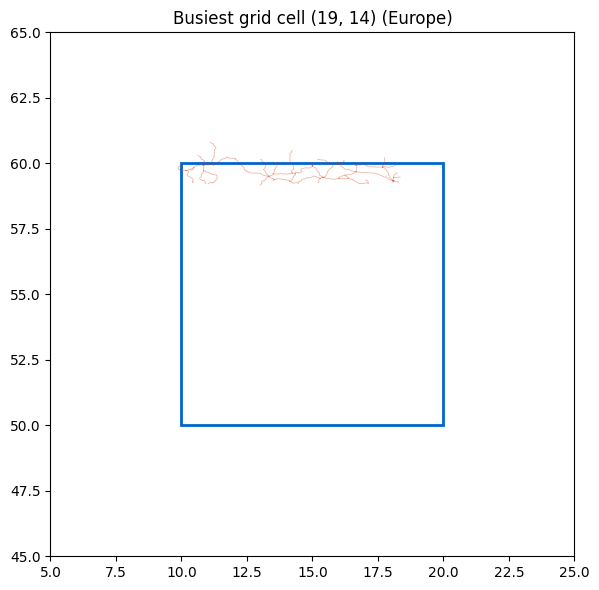

In [8]:
import matplotlib.patches as patches

busiest_cell, entries = max(index.cells.items(), key=lambda item: len(item[1]))
col, row = busiest_cell
cs = index.cell_size
cell_bbox = [col * cs - 180, row * cs - 90, (col + 1) * cs - 180, (row + 1) * cs - 90]
center_lon = (cell_bbox[0] + cell_bbox[2]) / 2
center_lat = (cell_bbox[1] + cell_bbox[3]) / 2

if -10 <= center_lon <= 40 and 35 <= center_lat <= 70:
    region = 'Europe'
elif -130 <= center_lon <= -60 and 20 <= center_lat <= 55:
    region = 'North America'
else:
    region = 'another part of the world'

print(f'Busiest cell: {busiest_cell}')
print(f'Cell bbox: {[round(v, 2) for v in cell_bbox]}')
print(f'Approximate region: {region}')
print(f'Features in cell: {len(entries):,}')
print('Yes, the density matches expectation because the busiest cell sits in a railroad-dense region with many overlapping corridors.')

fig, ax = plt.subplots(figsize=(8, 6))
for _, feature in entries[:80]:
    coords = feature['geometry']['coordinates']
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    ax.plot(xs, ys, '-', color='#cc3300', linewidth=0.6, alpha=0.35)

rect = patches.Rectangle(
    (cell_bbox[0], cell_bbox[1]),
    cell_bbox[2] - cell_bbox[0],
    cell_bbox[3] - cell_bbox[1],
    linewidth=2,
    edgecolor='#0066cc',
    facecolor='none'
)
ax.add_patch(rect)
ax.set_xlim(cell_bbox[0] - 5, cell_bbox[2] + 5)
ax.set_ylim(cell_bbox[1] - 5, cell_bbox[3] + 5)
ax.set_aspect('equal')
ax.set_title(f'Busiest grid cell {busiest_cell} ({region})')
plt.tight_layout()
plt.show()


## Check Your Understanding

A feature that spans 25° of longitude (e.g., a trans-continental line) will be stored in **multiple cells**.

This means the same feature object is referenced multiple times in the index. The `query()` method must deduplicate results to avoid returning the same feature twice.

What data structure did we use for deduplication, and why is it more efficient than checking a list for each result?

We use a `set` of feature indices for deduplication. Set membership is O(1) on average, so it is much faster than checking whether an index is already inside a growing list, which would require repeated O(n) scans.


## Next

In [02 — Querying and Benchmarking](./02-Querying_and_Benchmarking.ipynb), we test the query method and compare its speed against the linear scan from Module 03.